# Aula 13 - MLOps com Deep Dive em MLflow



**Por que precisamos de MLOps?**
1. **Reprodutibilidade:** Se o modelo der problema, você consegue recriar exatamente as condições em que ele foi treinado?
2. **Governança:** Quem treinou o modelo? Quais dados foram usados? Quais eram os hiperparâmetros?
3. **Monitoramento:** O modelo está perdendo performance (Data Drift / Concept Drift) ao longo do tempo?

Focaremos em uma das ferramentas mais populares do mercado para resolver os pontos 1 e 2: o **MLflow**.

In [10]:
# Instalando o MLflow no Google Colab
!pip install mlflow --quiet

## 🚀 Entrando no MLflow

O MLflow tem 4 componentes principais:
- **Tracking:** Registra parâmetros, métricas e artefatos (como o próprio arquivo do modelo).
- **Projects:** Empacota o código de forma reproduzível.
- **Models:** Formato padrão para empacotar modelos.
- **Registry:** Repositório central para gerenciar o ciclo de vida dos modelos (Staging, Production, etc.).

Vamos usar o **MLflow Tracking** para registrar o treinamento de um modelo usando o dataset Diabetes do `scikit-learn`.

In [11]:
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Carregar os dados
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir o nome do experimento no MLflow
mlflow.set_experiment("Aula_MLflow_Basico")

# 2. Iniciar uma rodada (run) do MLflow
with mlflow.start_run(run_name="RandomForest_Teste_Inicial"):
    # Hiperparâmetros
    n_estimators = 100
    max_depth = 5

    # Treinar o modelo
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Prever e calcular métricas
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    # 3. Registrar no MLflow
    # Registrando Parâmetros
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Registrando Métricas
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Registrando o Modelo (Artefato)
    mlflow.sklearn.log_model(model, "rf_model")

    print("\n✅ Treinamento concluído e registrado no MLflow com sucesso!")

2026/04/13 23:55:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MSE: 2881.58
R2 Score: 0.46


2026/04/13 23:55:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Treinamento concluído e registrado no MLflow com sucesso!


## Dicas do Tio: Versionamento de Modelos

Empresas perderem dinheiro por não versionarem seus modelos corretamente. Aqui estão as regras de ouro:

1. **Trate o modelo como código compilado:** O código, os dados de treino e o ambiente (requirements.txt) são o código-fonte. O modelo (`.pkl`, `.h5`) é o compilado. Versionem as entradas para poderem reproduzir as saídas.
2. **Use Tags no MLflow:** Sempre adicione tags aos seus *runs* como `versao_dados: v1.2`, `sprint: 45`, `ambiente: dev`. Isso salva vidas numa sexta-feira à noite quando a produção quebra.
3. **Registry não é lixeira:** Promova para os estágios `Staging` e `Production` apenas modelos que passaram por baterias de testes automatizados (unitários e de integração de dados).
4. **Shadow Deployment:** Antes de substituir um modelo v1 pelo v2, rode o v2 em modo "sombra" (recebendo requisições reais mas não impactando o cliente) e compare as métricas de negócio.

## Bônus Avançado: Autologging e Hyperparameter Tuning

Registrar manualmente cada parâmetro com `mlflow.log_param` pode ser tedioso. Vamos usar a magia do `mlflow.autolog()` integrado com um `GridSearchCV` para buscar os melhores hiperparâmetros. O MLflow criará um run principal e runs aninhados (nested) para cada combinação testada automaticamente!

In [12]:
from sklearn.model_selection import GridSearchCV

# Ativa o autologging para o scikit-learn
mlflow.sklearn.autolog()

mlflow.set_experiment("Aula_MLflow_Avancado_Tuning")

with mlflow.start_run(run_name="GridSearch_RF"):
    # Definir o modelo e o grid de hiperparâmetros
    rf = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    }

    # Configurar o GridSearch
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error')

    print("Treinando vários modelos... Isso pode levar alguns segundos.")
    # O Autolog registrará automaticamente cada combinação testada pelo GridSearch
    grid_search.fit(X_train, y_train)

    print("\n🏆 Melhor modelo encontrado:")
    print(grid_search.best_params_)

    # O MLflow registra magicamente o melhor estimador, suas métricas e todos os parâmetros de configuração!
    print("Tudo foi salvo no MLflow automaticamente graças ao autologging!")

Treinando vários modelos... Isso pode levar alguns segundos.


2026/04/13 23:56:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 23:56:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 23:56:33 INFO mlflow.sklearn.utils: Logging the 5 best runs, one run will be omitted.



🏆 Melhor modelo encontrado:
{'max_depth': 5, 'n_estimators': 100}
Tudo foi salvo no MLflow automaticamente graças ao autologging!


## 📊 Comparação de Modelos, Flavors e Model Registry

Vamos treinar um segundo modelo, um `GradientBoostingRegressor`, para podermos comparar com o nosso Random Forest.

Aqui, vamos explorar:
1. **Flavors:** Salvar o modelo explicitamente usando o flavor `sklearn`.
2. **Mais parâmetros:** Registrar hiperparâmetros específicos do Gradient Boosting.
3. **Gráficos:** Extrair os dados do MLflow para visualizar a comparação.
4. **Model Registry:** Registrar o melhor modelo para versionamento de produção.

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Desativar autologging para termos controle manual neste exemplo
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("Aula_MLflow_Comparacao")

with mlflow.start_run(run_name="GradientBoosting_Teste"):
    # Novos Hiperparâmetros
    learning_rate = 0.05
    n_estimators = 150
    max_depth = 4
    loss = 'squared_error'

    gb = GradientBoostingRegressor(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        loss=loss,
        random_state=42
    )
    gb.fit(X_train, y_train)

    predictions_gb = gb.predict(X_test)
    mse_gb = mean_squared_error(y_test, predictions_gb)
    r2_gb = r2_score(y_test, predictions_gb)

    # Registrando múltiplos parâmetros de uma vez
    mlflow.log_params({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "loss": loss,
        "algorithm": "GradientBoosting"
    })

    mlflow.log_metrics({
        "mse": mse_gb,
        "r2": r2_gb
    })

    # Registrando o modelo com Flavor Sklearn
    # O parametro 'registered_model_name' já envia o modelo direto para o Registry!
    mlflow.sklearn.log_model(gb, "model", registered_model_name="Preditor_Diabetes_GB")

    print(f"Gradient Boosting treinado! MSE: {mse_gb:.2f} | R2: {r2_gb:.2f}")

2026/04/13 23:56:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:56:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting treinado! MSE: 3243.80 | R2: 0.39


Registered model 'Preditor_Diabetes_GB' already exists. Creating a new version of this model...
Created version '2' of model 'Preditor_Diabetes_GB'.


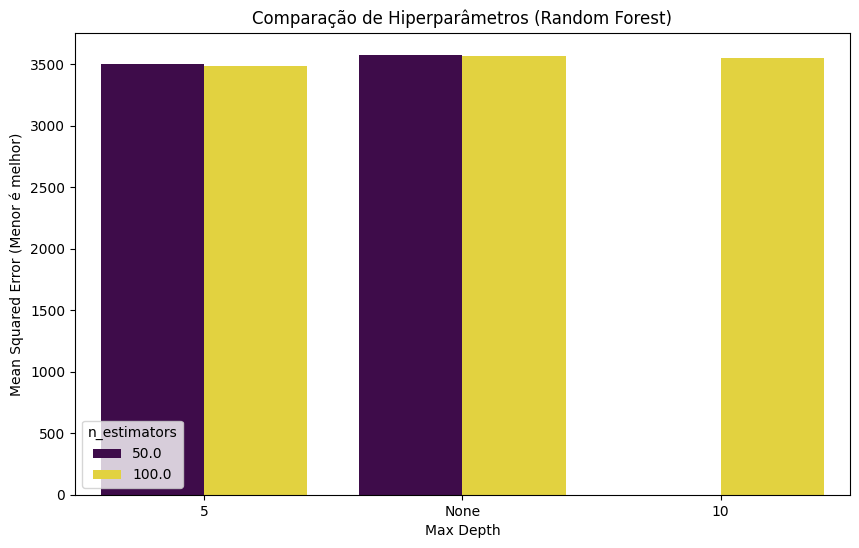

In [14]:
# 📈 Gráficos de Acompanhamento (Tracking)
# Vamos buscar os runs do nosso experimento de tunagem para analisar graficamente
experiment_name = "Aula_MLflow_Avancado_Tuning"
experiment = mlflow.get_experiment_by_name(experiment_name)

# search_runs retorna um DataFrame Pandas com todo o histórico do MLflow!
df_runs = mlflow.search_runs([experiment.experiment_id])

# Filtrar apenas os runs aninhados (que o GridSearch criou)
df_plot = df_runs[df_runs['tags.mlflow.parentRunId'].notnull()].copy()

if not df_plot.empty:
    # Limpar nomes das colunas para facilitar
    df_plot['max_depth'] = df_plot['params.max_depth'].fillna('None').astype(str)
    df_plot['n_estimators'] = df_plot['params.n_estimators'].astype(float)
    df_plot['mean_test_score'] = df_plot['metrics.mean_test_score'] * -1 # O MSE no GridSearch estava negativo

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x='max_depth', y='mean_test_score', hue='n_estimators', palette='viridis')
    plt.title('Comparação de Hiperparâmetros (Random Forest)')
    plt.ylabel('Mean Squared Error (Menor é melhor)')
    plt.xlabel('Max Depth')
    plt.show()
else:
    print("Execute o bloco do GridSearch primeiro para gerar os dados do gráfico.")

In [15]:
df_plot

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.mean_test_score,metrics.std_fit_time,metrics.mean_fit_time,metrics.rank_test_score,...,tags.estimator_class,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.parentRunId,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.autologging,max_depth,n_estimators,mean_test_score
0,06ccccf1e5494774aebf0a6b0f7aa7d9,2,FINISHED,/content/mlruns/2/06ccccf1e5494774aebf0a6b0f7a...,2026-04-13 23:56:00.227000+00:00,2026-04-13 23:56:33.654000+00:00,-3503.369877,0.027699,0.184311,2.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,d01fadde10f84908a8fd2c9e9684ca36,delicate-shrew-244,NOTEBOOK,sklearn,5,50.0,3503.369877
1,5d0adf57f6e94b7db9884c5c07e9cde9,2,FINISHED,/content/mlruns/2/5d0adf57f6e94b7db9884c5c07e9...,2026-04-13 23:56:00.227000+00:00,2026-04-13 23:56:33.654000+00:00,-3486.950784,0.237655,0.641459,1.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,d01fadde10f84908a8fd2c9e9684ca36,monumental-lark-607,NOTEBOOK,sklearn,5,100.0,3486.950784
2,a6c31abcf9204371adc0581d6de27c6d,2,FINISHED,/content/mlruns/2/a6c31abcf9204371adc0581d6de2...,2026-04-13 23:56:00.227000+00:00,2026-04-13 23:56:33.654000+00:00,-3564.593296,0.054182,0.536192,4.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,d01fadde10f84908a8fd2c9e9684ca36,upset-yak-280,NOTEBOOK,sklearn,None,100.0,3564.593296
4,d4c18bac92a945ed8dcf2cd8a0379a58,2,FINISHED,/content/mlruns/2/d4c18bac92a945ed8dcf2cd8a037...,2026-04-13 23:56:00.227000+00:00,2026-04-13 23:56:33.654000+00:00,-3546.118385,0.248797,0.764357,3.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,d01fadde10f84908a8fd2c9e9684ca36,enchanting-vole-205,NOTEBOOK,sklearn,10,100.0,3546.118385
5,ee14c8d4c0fd4892a6b52b9b1b0b8344,2,FINISHED,/content/mlruns/2/ee14c8d4c0fd4892a6b52b9b1b0b...,2026-04-13 23:56:00.227000+00:00,2026-04-13 23:56:33.654000+00:00,-3576.801707,0.064991,0.337268,5.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,d01fadde10f84908a8fd2c9e9684ca36,luxuriant-mole-561,NOTEBOOK,sklearn,None,50.0,3576.801707
6,3506bd6fa77845288167be78e372025c,2,FINISHED,/content/mlruns/2/3506bd6fa77845288167be78e372...,2026-04-13 22:36:57.339000+00:00,2026-04-13 22:37:26.901000+00:00,-3486.950784,0.008674,0.279005,1.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,49affcf2a5794968bc9b189315d98b67,adaptable-ray-746,NOTEBOOK,sklearn,5,100.0,3486.950784
8,4aeed8118df44d2db5ebfc5d66abb887,2,FINISHED,/content/mlruns/2/4aeed8118df44d2db5ebfc5d66ab...,2026-04-13 22:36:57.339000+00:00,2026-04-13 22:37:26.901000+00:00,-3564.593296,0.084866,1.136724,4.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,49affcf2a5794968bc9b189315d98b67,sedate-sponge-573,NOTEBOOK,sklearn,None,100.0,3564.593296
9,731058275ee245a284ab6780234c2a96,2,FINISHED,/content/mlruns/2/731058275ee245a284ab6780234c...,2026-04-13 22:36:57.339000+00:00,2026-04-13 22:37:26.901000+00:00,-3546.118385,0.022325,0.677491,3.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,49affcf2a5794968bc9b189315d98b67,polite-goose-292,NOTEBOOK,sklearn,10,100.0,3546.118385
10,ccbd2a4088d24bf28b7f037f40ce0881,2,FINISHED,/content/mlruns/2/ccbd2a4088d24bf28b7f037f40ce...,2026-04-13 22:36:57.339000+00:00,2026-04-13 22:37:26.901000+00:00,-3576.801707,0.024694,0.335985,5.0,...,sklearn.ensemble._forest.RandomForestRegressor,fileId=1d-rUG-vFgyEWKRNB_rZonn9m2l6fowSu,root,49affcf2a5794968bc9b189315d98b67,likeable-skunk-600,NOTEBOOK,sklearn,None,50.0,3576.801707
11,f2fdd395f7b4443b823d725193c1c387,2,FINISHED,/content/mlruns/2/f2fdd395f7b4443b823d725193c1...,2026-04-13 22:36:57.339000+00:00,2026-04-13 22:37:26.901000+00:00,-3503.369877,0.005479,0.158361,2.0,

In [16]:
# 🗄️ Trabalhando com o Model Registry via Client API
from mlflow.tracking import MlflowClient

client = MlflowClient()
model_name = "Preditor_Diabetes_GB"

# Vamos listar as versões do nosso modelo recém registrado
print(f"Versões do modelo '{model_name}':")
for mv in client.search_model_versions(f"name='{model_name}'"):
    print(f"Versão: {mv.version}, Estágio Atual: {mv.current_stage}, Status: {mv.status}")

# Promoção de Modelo: Vamos mover a versão 1 para o estágio de 'Staging'
client.transition_model_version_stage(
    name=model_name,
    version=1,
    stage="Staging"
)
print("\n✅ Modelo promovido para Staging!")

Versões do modelo 'Preditor_Diabetes_GB':
Versão: 2, Estágio Atual: None, Status: READY
Versão: 1, Estágio Atual: Staging, Status: READY

✅ Modelo promovido para Staging!


/tmp/ipykernel_14024/2967944318.py:13: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<!-- Célula de introdução antiga removida para evitar duplicação -->

## 🖥️ Acessando a Interface Gráfica do MLflow via Cloudflare

Até agora acessamos o MLflow via código (API Client). Mas o MLflow possui uma interface gráfica incrível (Tracking UI). Como estamos no Google Colab, vamos usar o `cloudflared` para criar um túnel seguro e expor a porta 5000 (onde o MLflow roda) para a internet!

In [17]:
import subprocess
import time
import threading
import re

# 1. Limpar processos antigos do mlflow e dar tempo para encerrar
get_ipython().system_raw("pkill -f mlflow")
time.sleep(2)

# 2. Iniciar o servidor MLflow em background na porta 5000 e host 0.0.0.0
get_ipython().system_raw("mlflow ui --host 0.0.0.0 --port 5000 &")
time.sleep(3) # Aguardar o MLflow subir

# 3. Baixar o Cloudflared para criar o túnel (se não existir)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1

url = None

# 4. Iniciar o túnel Cloudflare e capturar a URL gerada
def run_cloudflared():
    global url
    # Apontando para 127.0.0.1 e forçando o cabeçalho HTTP Host para 127.0.0.1 para evitar bloqueio de DNS Rebinding do MLflow
    process = subprocess.Popen(['cloudflared', 'tunnel', '--url', 'http://127.0.0.1:5000', '--http-host-header', '127.0.0.1'],
                               stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        match = re.search(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", line)
        if match:
            url = match.group(0)

threading.Thread(target=run_cloudflared, daemon=True).start()
print("Iniciando o servidor MLflow e o túnel Cloudflare... Aguardando o link...")

# Aguarda o link ser gerado por até 20 segundos
for _ in range(20):
    if url:
        print(f"\n🌐 A UI do MLflow está online! Acesse aqui: {url}\n")
        break
    time.sleep(1)
else:
    print("\n⚠️ O link demorou muito para ser gerado. Tente rodar a célula novamente.")

Iniciando o servidor MLflow e o túnel Cloudflare... Aguardando o link...

🌐 A UI do MLflow está online! Acesse aqui: https://phentermine-duke-conscious-trust.trycloudflare.com



## 🎛️ Inferência Gráfica: Apresentando o Modelo em Produção

Para apresentar nosso modelo aos stakeholders, não basta um notebook. Vamos criar uma interface gráfica usando **Gradio**.

Nesta interface, usaremos um componente de `Dropdown` para que o usuário escolha qual estágio do modelo ele quer consultar dinamicamente direto do nosso **Model Registry** (ex: testar o modelo que está em `Staging` ou o que já está em `Production`).

In [18]:
# Instalando o Gradio
!pip install gradio --quiet

import gradio as gr
import numpy as np
import mlflow.pyfunc

model_name = "Preditor_Diabetes_GB"

# Função de predição dinâmica
def predict_diabetes_dynamic(estagio, *features):
    try:
        # Carrega o modelo dinamicamente do Registry baseado no estágio escolhido na UI
        model_uri = f"models:/{model_name}/{estagio}"
        model = mlflow.pyfunc.load_model(model_uri)

        input_data = np.array([features])
        prediction = model.predict(input_data)
        return f"Progressão Estimada: {prediction[0]:.2f} (Modelo do Estágio: {estagio})"
    except Exception as e:
        return f"Erro ao carregar o modelo do estágio '{estagio}'. Verifique se ele existe no Registry. Detalhes: {str(e)}"

# Dropdown para o usuário escolher o estágio do Registry
stage_input = gr.Dropdown(choices=["None", "Staging", "Production"], value="Staging", label="Estágio do Modelo no Registry")

# Recuperando os inputs numéricos de antes (variável 'diabetes' já carregada no início da aula)
feature_names = diabetes.feature_names
numeric_inputs = [gr.Number(label=name, value=0.0) for name in feature_names]

# Juntando o dropdown com as numéricas
inputs = [stage_input] + numeric_inputs

# Criando a nova interface
iface_dynamic = gr.Interface(
    fn=predict_diabetes_dynamic,
    inputs=inputs,
    outputs=gr.Text(label="Resultado da Predição"),
    title="🩺 Previsor de Diabetes Dinâmico (MLOps)",
    description="Escolha a versão do modelo diretamente do MLflow Registry e faça a inferência!"
)

print("Iniciando a interface gráfica... Clique no link público (Public URL) abaixo para acessar!")
iface_dynamic.launch(share=True, debug=False)

Iniciando a interface gráfica... Clique no link público (Public URL) abaixo para acessar!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ee835aac600e411376.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
